# H4.5 provisional transonic fit

## tl;dr

The strict Plan 4.5 coverage gate remains failed. An explicitly provisional whole-trajectory replay fit was nevertheless run on the saved labels. With `alpha <= 3 deg`, the best two-free-knot model uses `CdA(0.90)=0.010604 m²`, `CdA(1.05)=0.022313 m²`, and the frozen H4 join `CdA(1.20)=0.023566 m²`. Its independent T4/G3 mean relative speed RMSE is about `0.24%` after excluding the imposed zero-residual initial state.

The stable result is mainly the `M≈1.0–1.2` rise. The `M0.90` value is not stable to the alpha filter and must not be frozen as an identified node.

## Context & Methods

This is a model-exploration notebook, not a replacement for the Phase-3 gate report. It compares:

- RM-10 normalized shape with `beta=1`;
- transferred supersonic `beta=1.669`;
- a fitted single `beta`;
- fitted `beta + slope`;
- a no-RM-10 three-knot log-linear control model (`K2`).

T1/T2 are fitted. T3 is a deterministic repeat, while T4 and historical G3 are independent diagnostics. Speed is replayed along observed altitude and flight-path angle. H4 is frozen at and above `M1.2`.

### Key Assumptions

- Visible labels at 2–4 s intervals represent the saved StatShark output correctly.
- Allowing alpha up to 3 deg yields an effective small-alpha drag measure; it is not strict zero-lift drag.
- Observed altitude and flight-path angle may be used as exogenous inputs for an axial-only replay.
- The first replay state is an imposed initial condition and is excluded from RMSE.

In [1]:
from pathlib import Path
import json
import runpy
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
SCRIPT_PATH = PROJECT_ROOT / 'scripts' / 'fit_h4_5_provisional.py'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'h4_5_transonic_drag' / 'provisional_fit'
assert SCRIPT_PATH.exists()
assert (PROJECT_ROOT / 'outputs' / 'h4_glide_drag' / 'cda_knots_fit.json').exists()
PROJECT_ROOT

WindowsPath('C:/software/Steam/steamapps/common/War Thunder/aim120_model_id')

## Data

Rerun the deterministic fit from the saved T1–T4 and G3 artifacts.

In [2]:
namespace = runpy.run_path(str(SCRIPT_PATH), run_name='h45_provisional_notebook')
assert namespace['main']() == 0
result = json.loads((OUTPUT_DIR / 'provisional_fit.json').read_text(encoding='utf-8'))

segment_rows = []
for sensitivity_name, sensitivity in result['sensitivity_fits'].items():
    for case_id, segment in sensitivity['segments'].items():
        segment_rows.append({'sensitivity': sensitivity_name, 'case_id': case_id, **segment})
pd.DataFrame(segment_rows)

recommended K2_log_knots
P0_beta_1 params= {'beta': 1.0, 'slope': 0.0} train_rmse= 0.013867918284497748 validation_rmse= 0.007570617897386918
P0b_beta_1p669 params= {'beta': 1.668993602463756, 'slope': 0.0} train_rmse= 0.006206999987980116 validation_rmse= 0.004023949122398733
P1_beta_free params= {'beta': 1.9946666666666668, 'slope': 0.0} train_rmse= 0.004987238947806241 validation_rmse= 0.0034987681780374686
P2_beta_slope params= {'beta': 1.1848958333333335, 'slope': -0.625} train_rmse= 0.0015940491274078874 validation_rmse= 0.0030635803172399893
K2_log_knots params= {'cda_m09_m2': 0.01060421558560114, 'cda_m105_m2': 0.0223132923273266, 'cda_m12_m2': 0.023565906388471742} train_rmse= 0.0016648205705061027 validation_rmse= 0.0024130293572959473


,sensitivity,case_id,sample_count,mach_min,mach_max,time_min_s,time_max_s
0,alpha_2p5,T1,3,0.99,1.23,2.02,10.00
1,alpha_2p5,T2,3,0.99,1.15,0.00,6.02
2,alpha_2p5,T3,3,0.99,1.23,2.02,10.00
3,alpha_2p5,T4,2,1.13,1.25,2.02,6.02
4,alpha_2p5,G3,5,0.99,1.23,6.02,14.00
5,alpha_3p0,T1,4,0.93,1.23,2.02,14.00
6,alpha_3p0,T2,5,0.91,1.15,0.00,12.00
7,alpha_3p0,T3,4,0.93,1.23,2.02,14.00
8,alpha_3p0,T4,3,1.03,1.25,2.02,10.00
9,alpha_3p0,G3,8,0.91,1.23,6.02,20.00


## Results

### Model comparison at alpha <= 3 deg

In [3]:
primary = result['sensitivity_fits']['alpha_3p0']
comparison_rows = []
for model_name in primary['ranking_by_independent_validation']:
    model = primary['models'][model_name]
    comparison_rows.append({
        'model': model_name,
        'parameters': json.dumps(model['parameters'], sort_keys=True),
        'train relative RMSE (%)': 100 * model['training_mean_relative_rmse'],
        'T4/G3 relative RMSE (%)': 100 * model['independent_validation_mean_relative_rmse'],
        'T3 repeat RMSE (%)': 100 * model['repeat_T3_relative_rmse'],
    })
pd.DataFrame(comparison_rows)

,model,parameters,train relative RMSE (%),T4/G3 relative RMSE (%),T3 repeat RMSE (%)
0,K2_log_knots,"{""cda_m09_m2"": 0.01060421558560114, ""cda_m105_...",0.166482,0.241303,0.168922
1,P2_beta_slope,"{""beta"": 1.1848958333333335, ""slope"": -0.625}",0.159405,0.306358,0.150822
2,P1_beta_free,"{""beta"": 1.9946666666666668, ""slope"": 0.0}",0.498724,0.349877,0.463210
3,P0b_beta_1p669,"{""beta"": 1.668993602463756, ""slope"": 0.0}",0.620700,0.402395,0.608211
4,P0_beta_1,"{""beta"": 1.0, ""slope"": 0.0}",1.386792,0.757062,1.271315


### Exact curve lookup and alpha-filter sensitivity

In [4]:
lookup_mach = {0.90, 0.95, 1.00, 1.05, 1.10, 1.15, 1.20}
curve_table = pd.DataFrame([row for row in primary['curve_rows'] if round(row['mach'], 2) in lookup_mach])
display(curve_table)

alpha_rows = []
for sensitivity_name in ('alpha_2p5', 'alpha_3p0'):
    sensitivity = result['sensitivity_fits'][sensitivity_name]
    k2 = sensitivity['models']['K2_log_knots']['parameters']
    p1 = sensitivity['models']['P1_beta_free']['parameters']
    alpha_rows.append({
        'sensitivity': sensitivity_name,
        'supported Mach min (T1/T2)': min(sensitivity['segments']['T1']['mach_min'], sensitivity['segments']['T2']['mach_min']),
        'K2 CdA M0.90': k2['cda_m09_m2'],
        'K2 CdA M1.05': k2['cda_m105_m2'],
        'P1 beta': p1['beta'],
    })
pd.DataFrame(alpha_rows)

,mach,P0_beta_1,P0b_beta_1p669,P1_beta_free,P2_beta_slope,K2_log_knots
0,0.90,0.015163,0.011289,0.009779,0.011586,0.010604
1,0.95,0.016259,0.012684,0.011239,0.012984,0.013589
2,1.00,0.021465,0.020165,0.019561,0.018619,0.017413
3,1.05,0.023475,0.023414,0.023384,0.021358,0.022313
4,1.10,0.023931,0.024179,0.024300,0.022545,0.022723
5,1.15,0.023749,0.023872,0.023932,0.023051,0.023141
6,1.20,0.023566,0.023566,0.023566,0.023566,0.023566


,sensitivity,supported Mach min (T1/T2),K2 CdA M0.90,K2 CdA M1.05,P1 beta
0,alpha_2p5,0.99,0.017018,0.021512,3.291333
1,alpha_3p0,0.91,0.010604,0.022313,1.994667


### Curve and whole-trajectory residuals

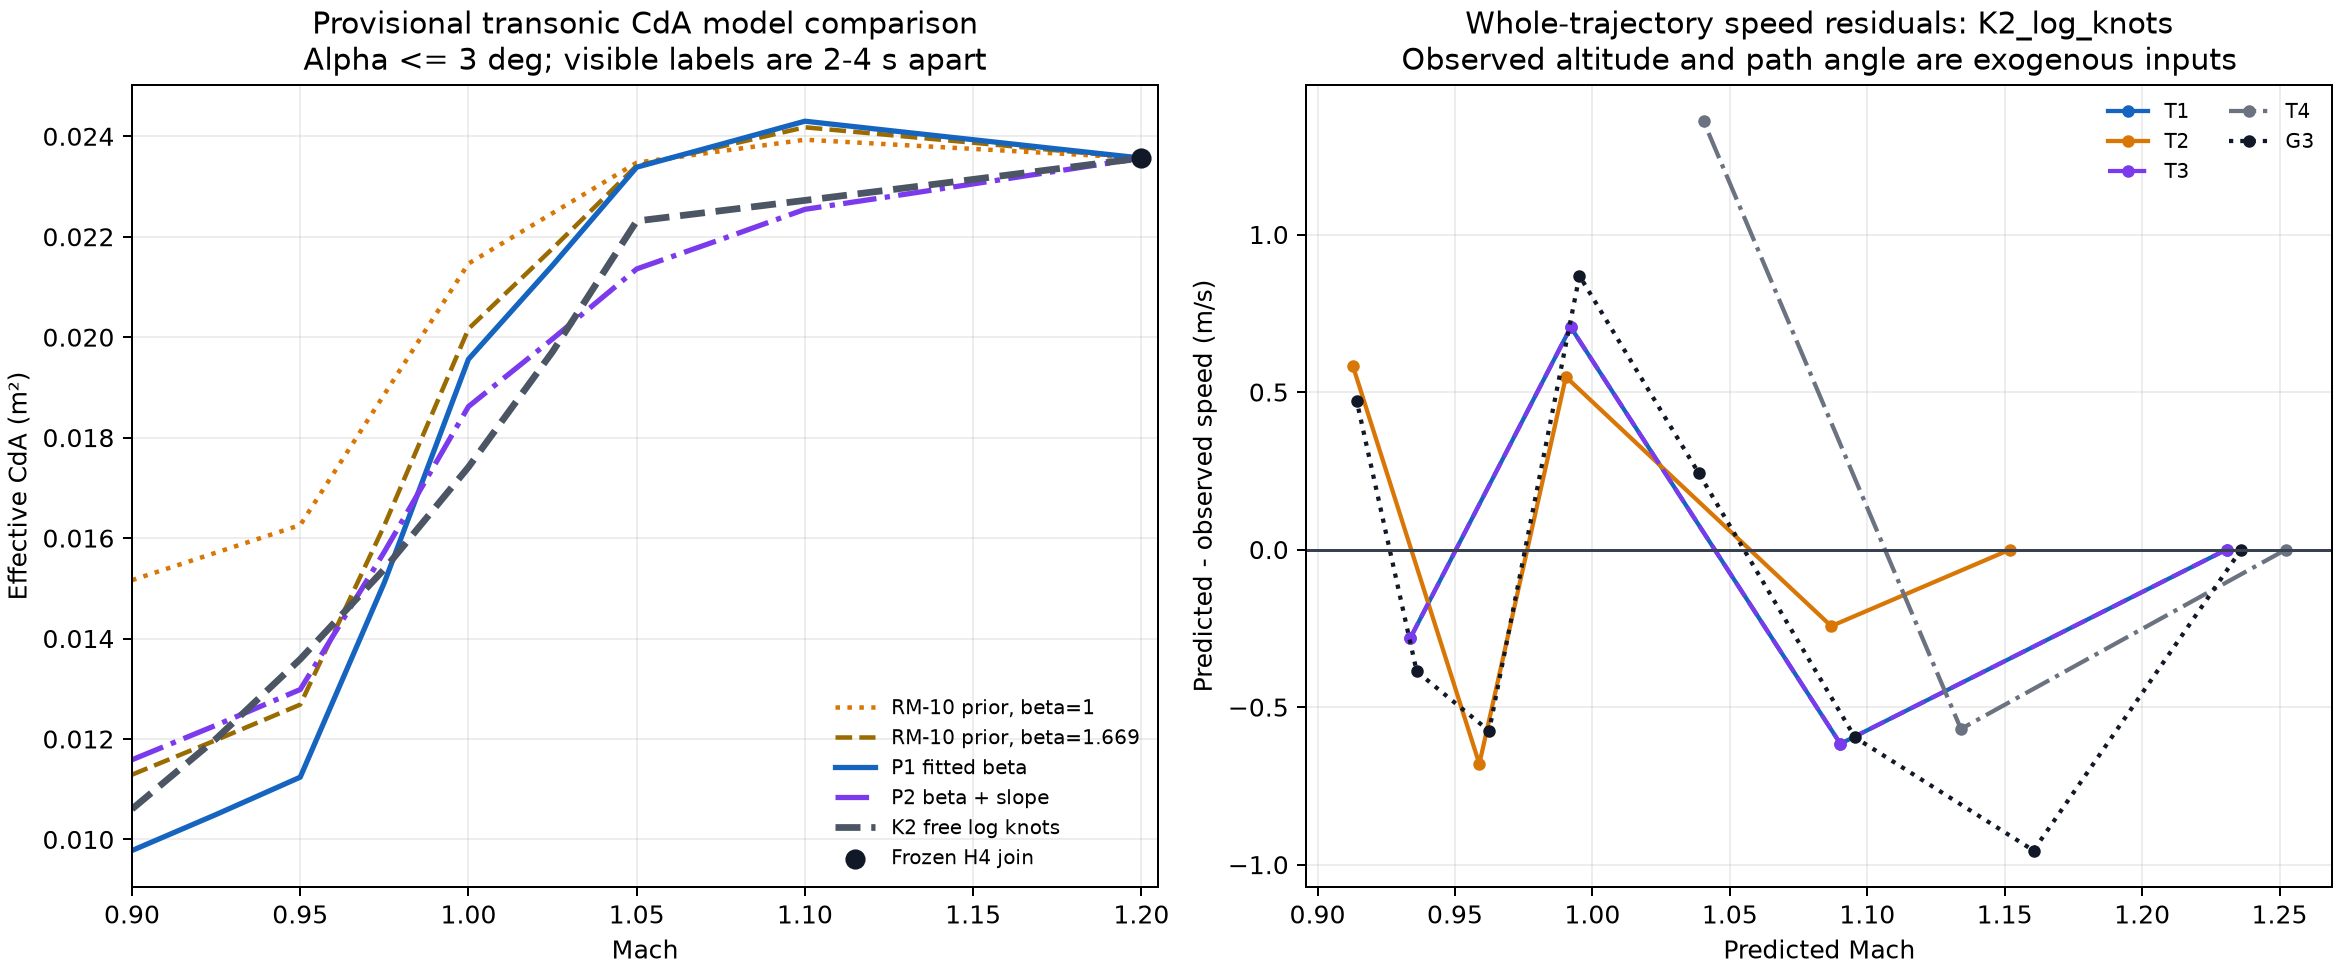

In [5]:
display(Image(filename=str(OUTPUT_DIR / 'h4_5_provisional_fit.png')))

## Takeaways

1. The data support a sharp reduction in effective CdA below roughly `M1.0–1.05`; the fitted center node near `M1.05` is comparatively stable across the 2.5 deg and 3 deg filters.
2. The `M0.90` endpoint is not stable. The stricter dataset only reaches about `M0.99`, so its M0.90 knot is an extrapolated fit parameter.
3. The RM-10-derived single-beta model is directionally useful, but beta changes materially with the alpha filter. It is not ready to freeze.
4. K2 improves independent replay error, but sparse labels, short segments, and alpha coupling keep the result provisional.
5. No H4 node at or above `M1.2` was modified.